# Exploratory Data Analysis.

In [1]:
# 1. Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

## 1.Data Cleaning and Preparation:

In [2]:
# Loading the dataset into dataframe.
df = pd.read_csv("Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
df.shape

(2126, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
# Checking for missing values.
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [6]:
# Handle missing values appropriately.
# Mean imputation (continuous)
mean_cols = ["LB", "MSTV", "MLTV", "Width"]
df[mean_cols] = df[mean_cols].fillna(df[mean_cols].mean())
# Median imputation (skewed / outliers)
median_cols = ["AC", "FM", "UC", "DL", "DS", "DP", "ASTV", "ALTV"]
df[median_cols] = df[median_cols].fillna(df[median_cols].median())
# Mode imputation (categorical)
df["Tendency"].fillna(df["Tendency"].mode()[0], inplace=True)
df["NSP"].fillna(df["NSP"].mode()[0], inplace=True)
 #NSP = Fetal State Class
df = df[df["NSP"].isin([1, 2, 3])]
# Fix invalid negative values (except Tendency)
for col in mean_cols + median_cols:
    df.loc[df[col] < 0, col] = df[col].median()

df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [7]:
# Removinng dupllicates
df=df.drop_duplicates()

In [8]:
# All variables are numerical - No datatype correction needed
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [9]:
df["NSP"].unique()

array([2., 1., 3.])

In [10]:
# Converting Target varible from float to int.
df["NSP"] = df["NSP"].astype(int)

In [11]:
# Detect and treat outliers.
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
outliers

LB            9
AC           32
FM          317
UC            9
DL          107
DS           62
DP          218
ASTV          4
MSTV         72
ALTV        296
MLTV         73
Width         4
Tendency     10
NSP         442
dtype: int64

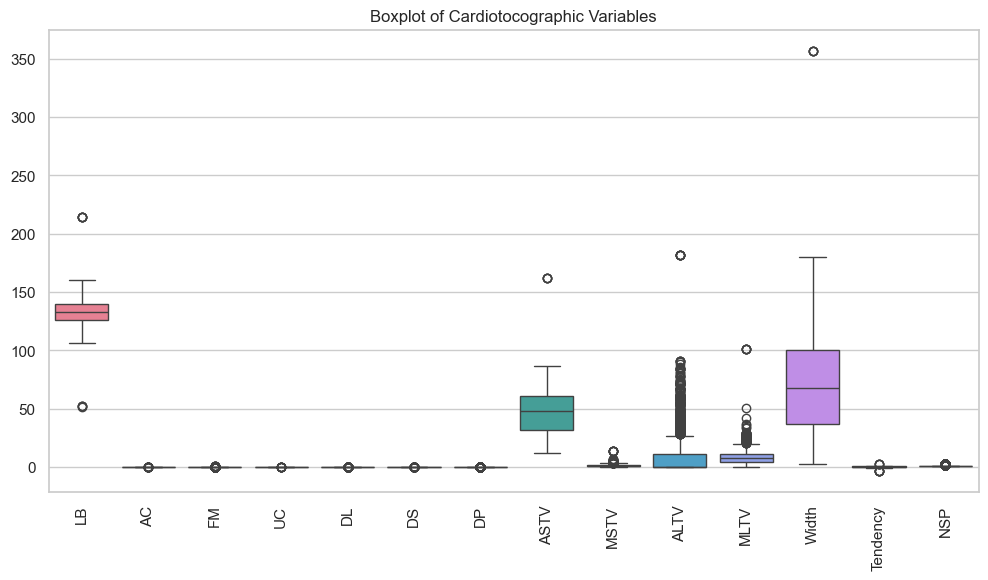

In [12]:
# These outliers are clinically meaningful and should not be removed blindly, as they may indicate fetal distress.
# Retained to preserve medical relevance
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Cardiotocographic Variables")
plt.show()

## 2.Statistical Summary:


In [13]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,1984.0,133.312745,11.252749,51.842487,126.000000,133.000000,140.010442,214.000000
AC,1984.0,0.003288,0.004226,0.000000,0.000000,0.001663,0.005651,0.038567
FM,1984.0,0.011638,0.063873,0.000000,0.000000,0.000000,0.002521,0.961268
UC,1984.0,0.004455,0.003242,0.000000,0.001965,0.004484,0.006570,0.030002
DL,1984.0,0.001931,0.003162,0.000000,0.000000,0.000000,0.003304,0.030769
DS,1984.0,0.000007,0.000119,0.000000,0.000000,0.000000,0.000000,0.002706
DP,1984.0,0.000183,0.000783,0.000000,0.000000,0.000000,0.000000,0.010695
ASTV,1984.0,47.153322,17.944382,11.799846,32.000000,48.000000,61.000000,162.000000
MSTV,1984.0,1.376297,1.146217,0.200000,0.700000,1.200000,1.700000,13.800000
ALTV,1984.0,10.467957,21.042733,0.000000,0.000000,0.000000,11.000000,182.000000


In [14]:
# Examine the NSP column more closely as it's our target variable.
# NSP Meaning.
# 1 → Normal
# 2 → Suspect
# 3 → Pathologic
df['NSP'].value_counts().sort_index()

NSP
1    1542
2     279
3     163
Name: count, dtype: int64

In [15]:
# The proportion of NSP values
df['NSP'].value_counts(normalize=True)

NSP
1    0.777218
2    0.140625
3    0.082157
Name: proportion, dtype: float64

In [16]:
# Correlation analysis
correlation_matrix = df.corr()
print("\nTop Correlations with NSP:")
nsp_correlations = correlation_matrix['NSP'].sort_values(ascending=False)
print(nsp_correlations)


Top Correlations with NSP:
NSP         1.000000
ASTV        0.455366
ALTV        0.379635
DP          0.346185
LB          0.138711
FM          0.083479
DS          0.071837
DL          0.057747
Width      -0.065427
MSTV       -0.085202
Tendency   -0.122488
MLTV       -0.132996
UC         -0.199900
AC         -0.325364
Name: NSP, dtype: float64


## 3.Data Visualization:

In [17]:
# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

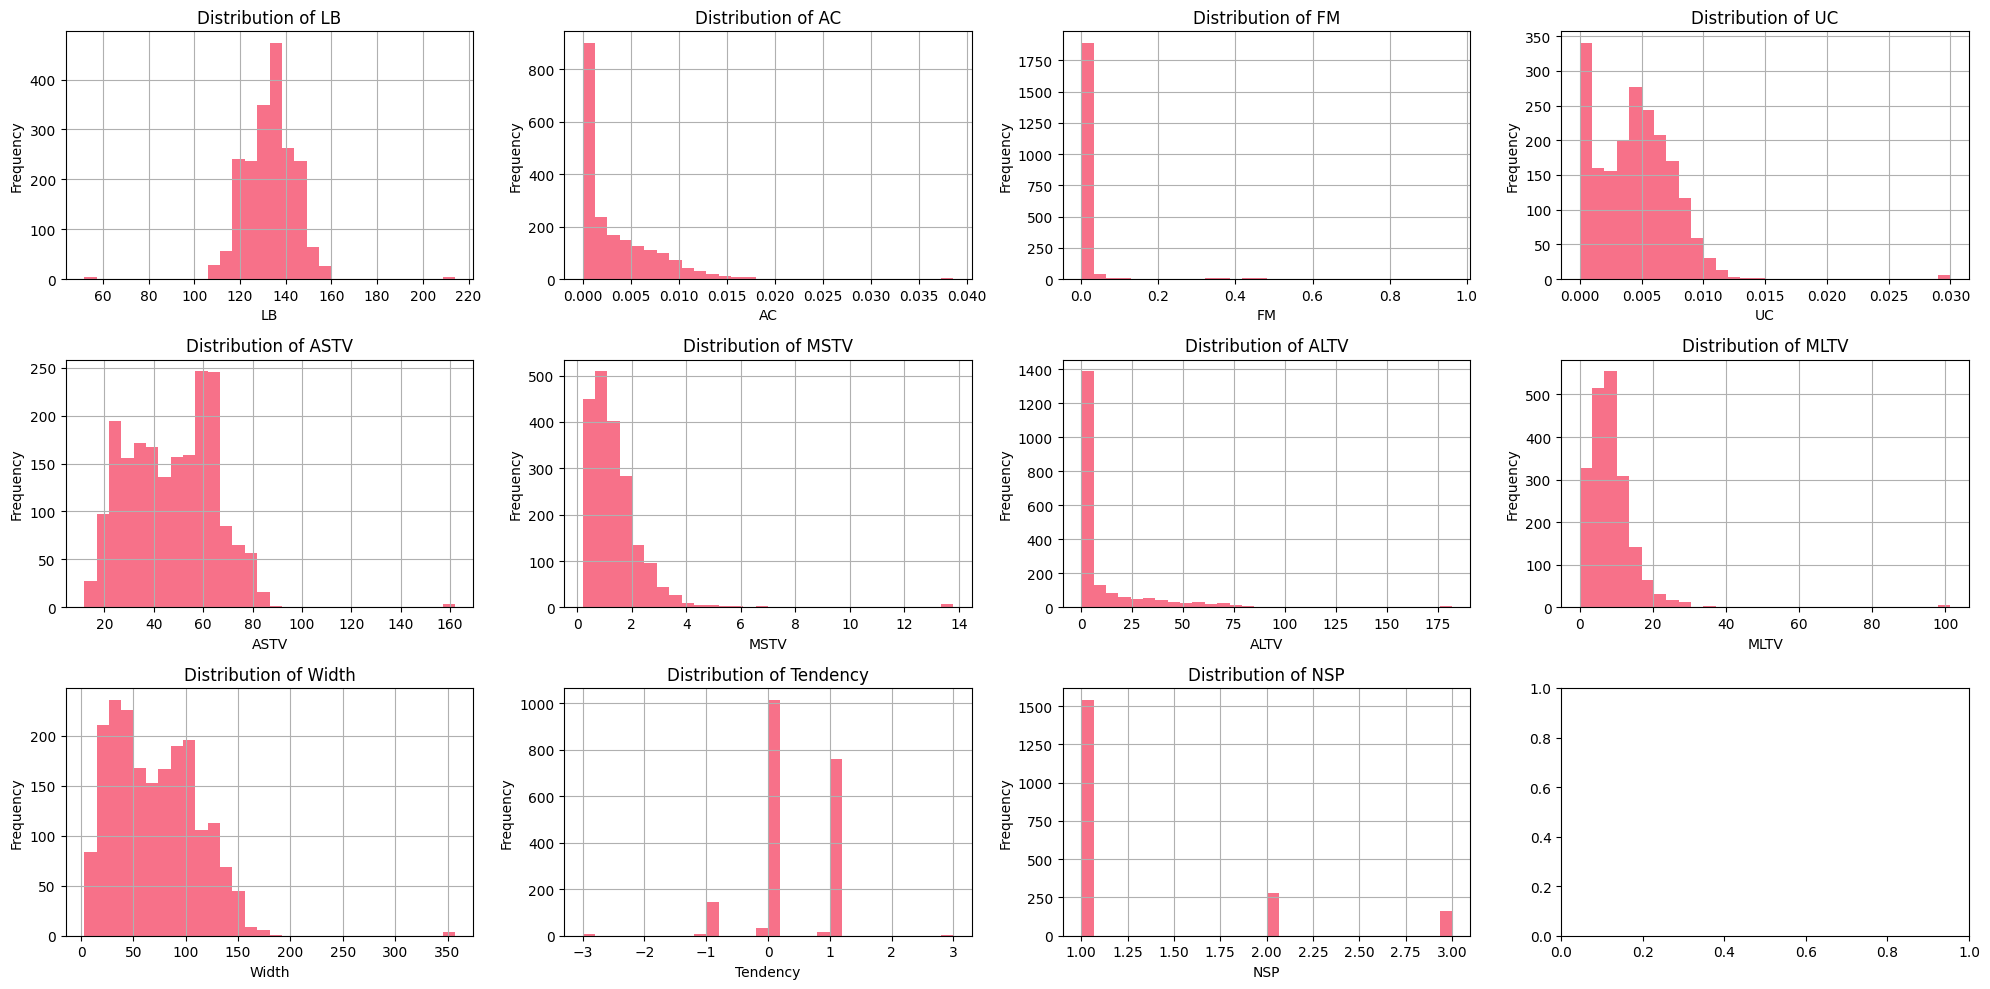

In [18]:
# Histograms for Key Variables
key_variables = ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, var in enumerate(key_variables):
    df[var].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

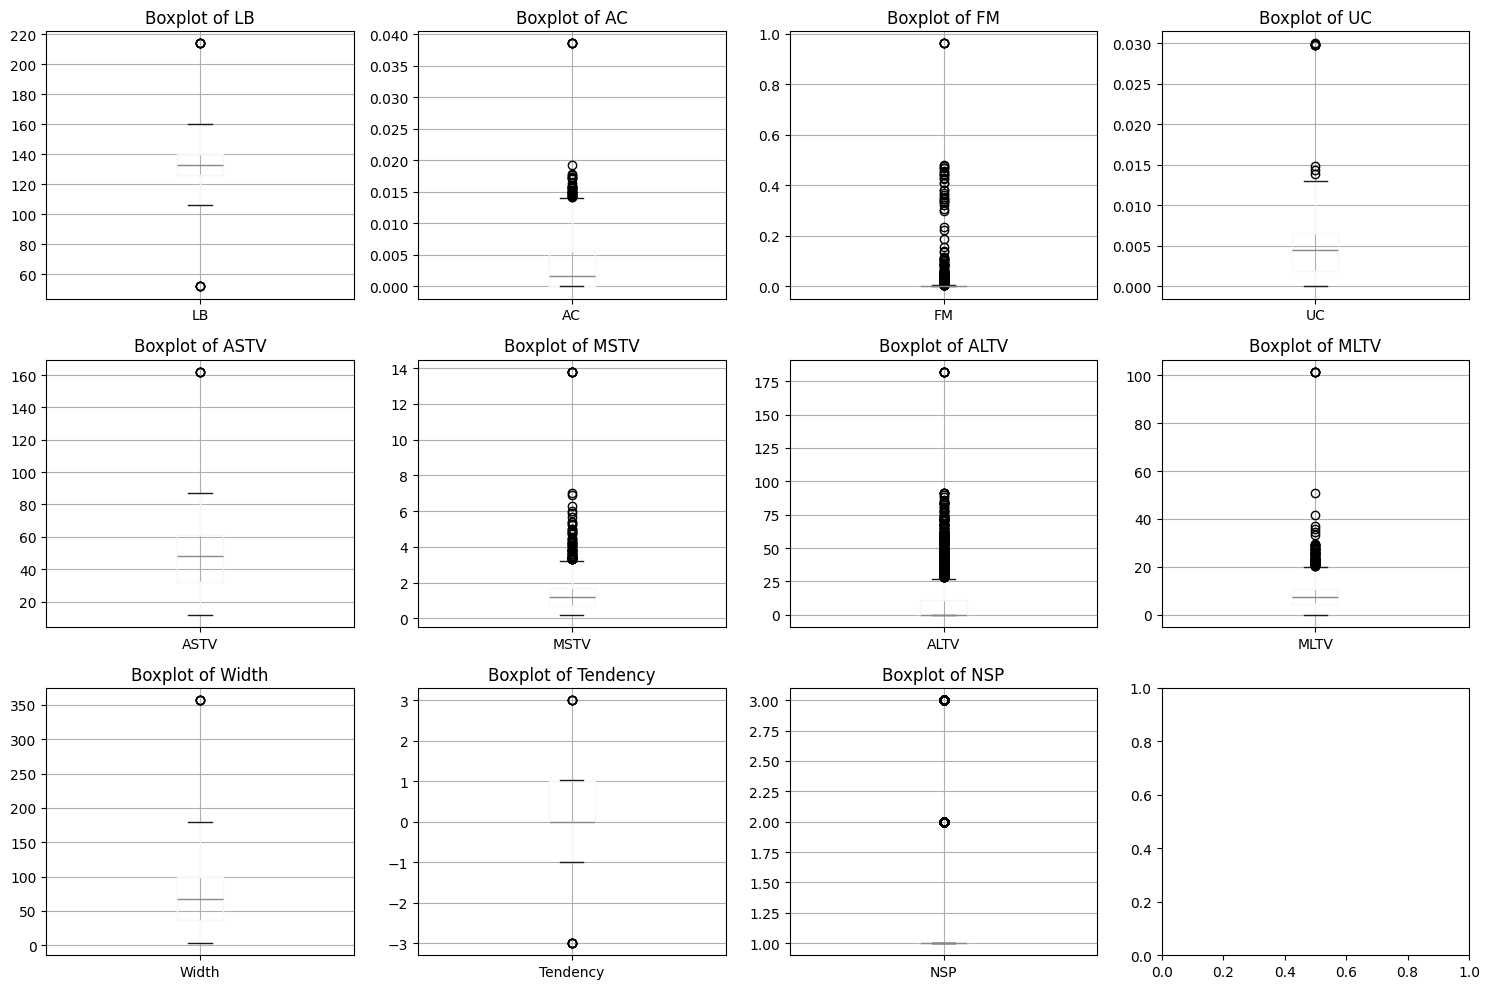

In [19]:
# Boxplots to Identify Outliers
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(key_variables):
    df.boxplot(column=var, ax=axes[i])
    axes[i].set_title(f'Boxplot of {var}')

plt.tight_layout()
plt.show()

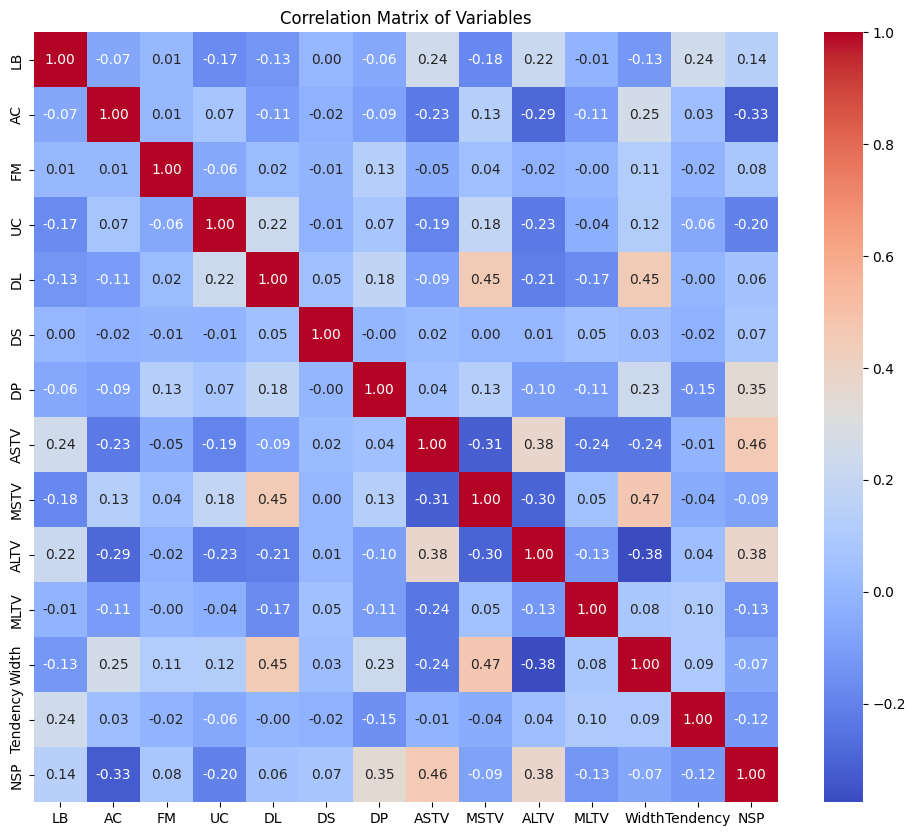

Top 5 variables most correlated with NSP:
ASTV    0.455366
ALTV    0.379635
DP      0.346185
AC     -0.325364
UC     -0.199900
Name: NSP, dtype: float64


In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

# Top correlations with NSP
nsp_correlations = correlation_matrix['NSP'].drop('NSP').sort_values(key=abs, ascending=False)
print("Top 5 variables most correlated with NSP:")
print(nsp_correlations.head())

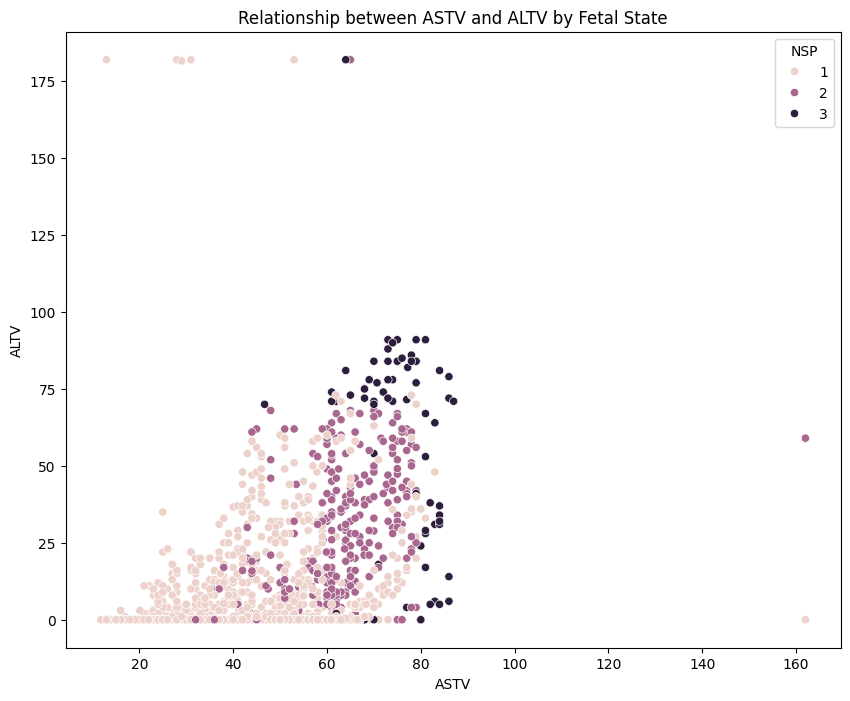

In [21]:
# Scatter Plot of Most Correlated Variables
# Selecting two variables with highest correlation to NSP
top_corr_vars = nsp_correlations.index[:2].tolist()
if len(top_corr_vars) >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=top_corr_vars[0], y=top_corr_vars[1], hue='NSP', data=df)
    plt.title(f'Relationship between {top_corr_vars[0]} and {top_corr_vars[1]} by Fetal State')
    plt.show()

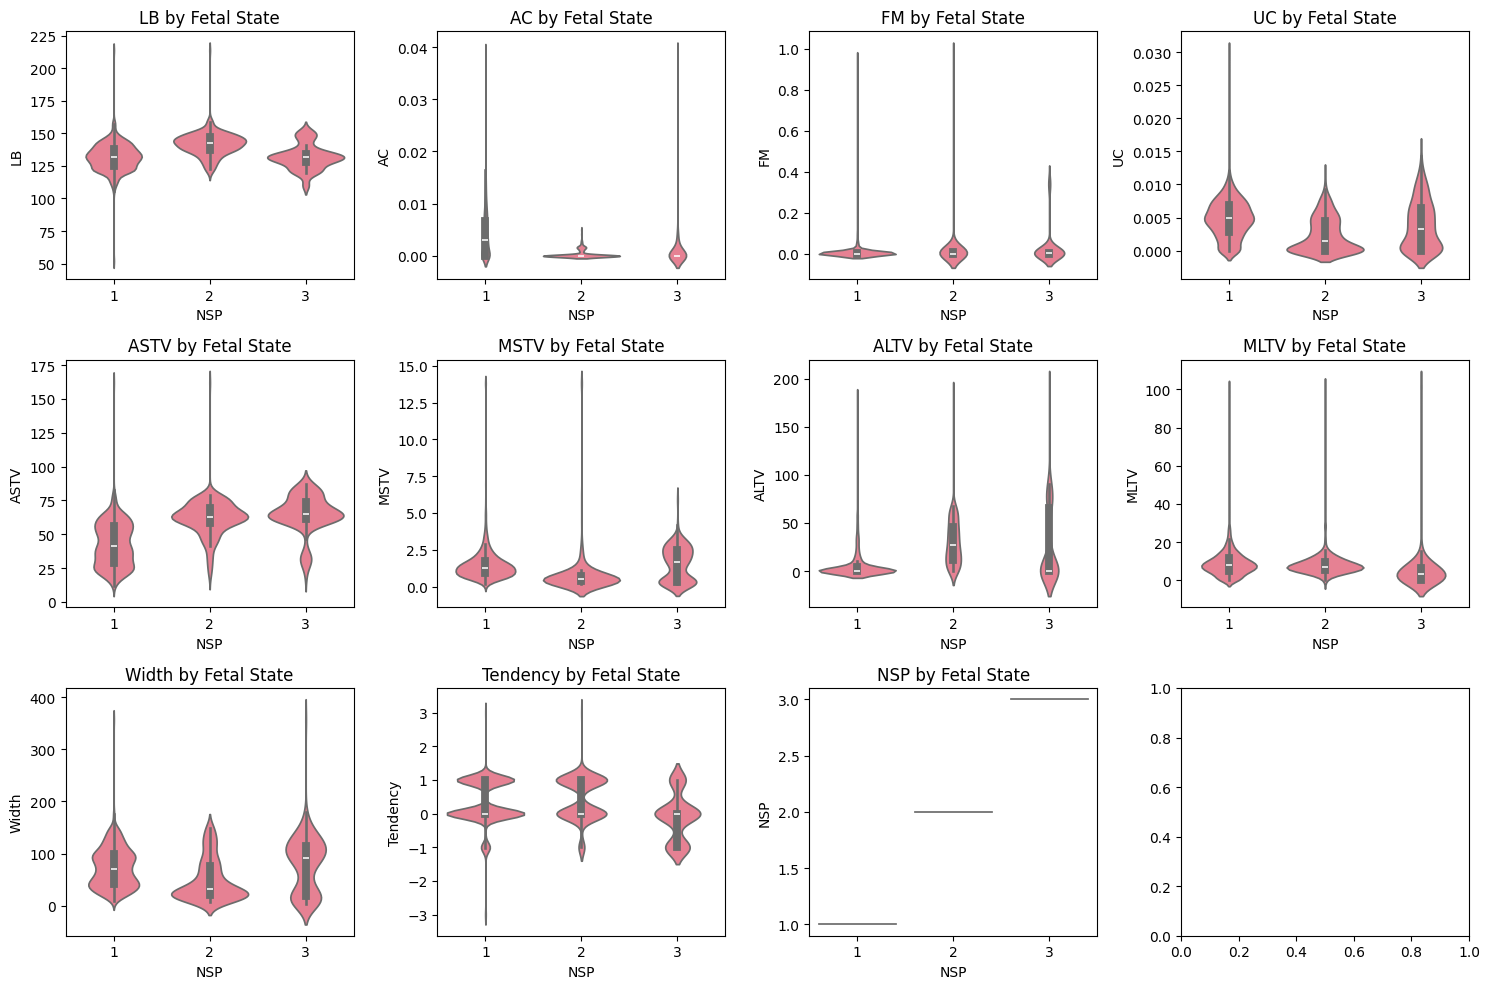

In [22]:
# Violin Plots
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(key_variables):
    sns.violinplot(x='NSP', y=var, data=df, ax=axes[i])
    axes[i].set_title(f'{var} by Fetal State')

plt.tight_layout()
plt.show()

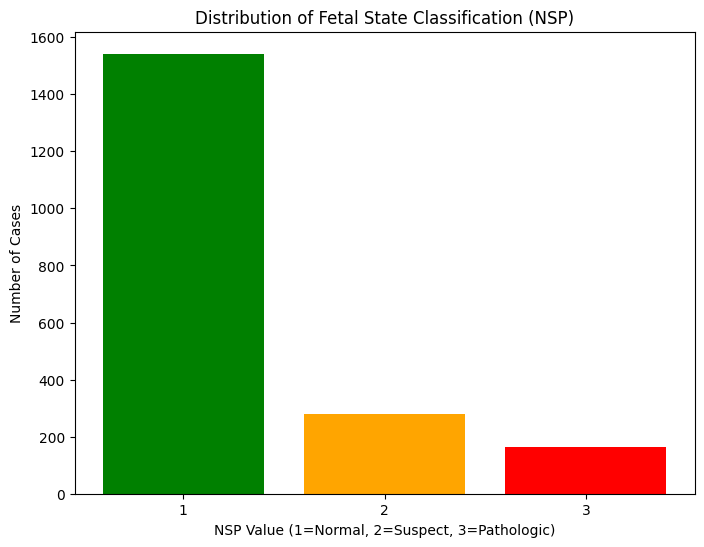

NSP Distribution:
Normal (1): 1542 cases
Suspect (2): 279 cases
Pathologic (3): 163 cases


In [23]:
# Distribution of Target Variable (NSP)
plt.figure(figsize=(8, 6))
nsp_counts = df['NSP'].value_counts().sort_index()
plt.bar(nsp_counts.index.astype(str), nsp_counts.values, color=['green', 'orange', 'red'])
plt.title('Distribution of Fetal State Classification (NSP)')
plt.xlabel('NSP Value (1=Normal, 2=Suspect, 3=Pathologic)')
plt.ylabel('Number of Cases')
plt.show()

print("NSP Distribution:")
print(f"Normal (1): {nsp_counts[1]} cases")
print(f"Suspect (2): {nsp_counts[2]} cases") 
print(f"Pathologic (3): {nsp_counts[3]} cases")

## 4.Pattern Recognition and Insights:

In [24]:
# Pattern 1: Analyze relationships between variables and NSP
if 'NSP' in df.columns:
    # Group by NSP and calculate mean values
    nsp_grouped = df.groupby('NSP').mean()
    print("Mean Values by NSP:")
    print(nsp_grouped)

Mean Values by NSP:
             LB        AC        FM        UC        DL        DS        DP  \
NSP                                                                           
1    131.928037  0.004098  0.008873  0.004899  0.001966  0.000002  0.000084   
2    141.812176  0.000329  0.018943  0.002367  0.000752  0.000019  0.000092   
3    131.864151  0.000688  0.025286  0.003823  0.003621  0.000028  0.001272   

          ASTV      MSTV       ALTV      MLTV      Width  Tendency  
NSP                                                                 
1    42.594319  1.471585   5.590477  8.857474  73.884946  0.329487  
2    61.913460  0.748884  29.545221  8.378447  49.577676  0.433308  
3    65.017759  1.548772  23.955789  4.926011  79.154032 -0.091865  


In [25]:
# Statistical test for differences between NSP groups
print("\nANOVA Results (comparing means across NSP groups):")
for var in key_variables:
        if var in df.columns:
            groups = [df[df['NSP'] == i][var] for i in sorted(df['NSP'].unique())]
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"{var}: F-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")


ANOVA Results (comparing means across NSP groups):
LB: F-statistic = 102.05, p-value = 0.0000
AC: F-statistic = 146.23, p-value = 0.0000
FM: F-statistic = 7.03, p-value = 0.0009
UC: F-statistic = 81.61, p-value = 0.0000
ASTV: F-statistic = 290.63, p-value = 0.0000
MSTV: F-statistic = 51.46, p-value = 0.0000
ALTV: F-statistic = 234.14, p-value = 0.0000
MLTV: F-statistic = 21.93, p-value = 0.0000
Width: F-statistic = 47.40, p-value = 0.0000
Tendency: F-statistic = 38.73, p-value = 0.0000
NSP: F-statistic = inf, p-value = 0.0000


In [26]:
# Correlation analysis with NSP.
# Correlation matrix.
corr_matrix = df.corr()
# Extract correlations with target variable NSP.
corr_with_nsp = corr_matrix['NSP'].sort_values(ascending=False)
corr_with_nsp

NSP         1.000000
ASTV        0.455366
ALTV        0.379635
DP          0.346185
LB          0.138711
FM          0.083479
DS          0.071837
DL          0.057747
Width      -0.065427
MSTV       -0.085202
Tendency   -0.122488
MLTV       -0.132996
UC         -0.199900
AC         -0.325364
Name: NSP, dtype: float64

In [27]:
# Compare means by NSP category.
# Group data by NSP and calculate mean of each feature.
mean_by_nsp = df.groupby('NSP').mean()
mean_by_nsp

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
NSP,,,,,,,,,,,,,
1,131.928037,0.004098,0.008873,0.004899,0.001966,0.000002,0.000084,42.594319,1.471585,5.590477,8.857474,73.884946,0.329487
2,141.812176,0.000329,0.018943,0.002367,0.000752,0.000019,0.000092,61.913460,0.748884,29.545221,8.378447,49.577676,0.433308
3,131.864151,0.000688,0.025286,0.003823,0.003621,0.000028,0.001272,65.017759,1.548772,23.955789,4.926011,79.154032,-0.091865


In [28]:
# Identify potential clinical thresholds (using NSP group statistics).
# Calculate mean and median of key features by NSP
thresholds = df.groupby('NSP')[key_variables].agg(['mean', 'median'])
thresholds

LB               AC                  FM                  UC  \
           mean median      mean    median      mean    median      mean   
NSP                                                                        
1    131.928037  132.0  0.004098  0.002981  0.008873  0.000000  0.004899   
2    141.812176  143.0  0.000329  0.000000  0.018943  0.000000  0.002367   
3    131.864151  132.0  0.000688  0.000000  0.025286  0.001009  0.003823   

                    ASTV         ...       ALTV             MLTV         \
       median       mean median  ...       mean median      mean median   
NSP                              ...                                      
1    0.004890  42.594319   41.0  ...   5.590477    0.0  8.857474    8.0   
2    0.001502  61.913460   63.0  ...  29.545221   27.0  8.378447    7.1   
3    0.003311  65.017759   65.0  ...  23.955789    0.0  4.926011    3.5   

         Width         Tendency         NSP         
          mean median      mean median mean median  
NSP                                                 
1    73.884946   71.0  0.329487    0.0  1.0    1.0  
2    49.577676   32.0  0.433308    0.0  2.0    2.0  
3    79.154032   91.0 -0.091865    0.0  3.0    3.0  

[3 rows x 22 columns]

In [29]:
# Analyze deceleration patterns (DL, DS, DP) across NSP groups
deceleration_cols = ['DL', 'DS', 'DP']
# Summary statistics by NSP
decel_stats = df.groupby('NSP')[deceleration_cols].mean()
decel_stats

,DL,DS,DP
NSP,,,
1,0.001966,0.000002,0.000084
2,0.000752,0.000019,0.000092
3,0.003621,0.000028,0.001272


In [30]:
# Analyze variability metrics (ASTV, MSTV, ALTV, MLTV) across NSP groups
variability_cols = ['ASTV', 'MSTV', 'ALTV', 'MLTV']
# Mean variability values by NSP
variability_stats = df.groupby('NSP')[variability_cols].mean()
variability_stats

,ASTV,MSTV,ALTV,MLTV
NSP,,,,
1,42.594319,1.471585,5.590477,8.857474
2,61.913460,0.748884,29.545221,8.378447
3,65.017759,1.548772,23.955789,4.926011


In [31]:
# Multivariate Pattern Recognition
print("\nMULTIVARIATE PATTERNS AND INTERACTIONS")
print("="*50)
# Analyze interactions between key variables
print("Interaction analysis - How variables work together:")
# ASTV and DL interaction
high_astv_high_dl = df[(df['ASTV'] > df['ASTV'].median()) & 
                            (df['DL'] > df['DL'].median())]
low_astv_low_dl = df[(df['ASTV'] <= df['ASTV'].median()) & 
                          (df['DL'] <= df['DL'].median())]

print(f"High ASTV + High DL: {len(high_astv_high_dl)} cases, "
      f"{high_astv_high_dl['NSP'].value_counts(normalize=True).get(3, 0):.1%} pathological")
print(f"Low ASTV + Low DL: {len(low_astv_low_dl)} cases, "
      f"{low_astv_low_dl['NSP'].value_counts(normalize=True).get(3, 0):.1%} pathological")


MULTIVARIATE PATTERNS AND INTERACTIONS
Interaction analysis - How variables work together:
High ASTV + High DL: 410 cases, 20.2% pathological
Low ASTV + Low DL: 540 cases, 0.4% pathological


## 5.Conclusion:

In [32]:
nsp_distribution = df['NSP'].value_counts().sort_index()

In [ ]:
# Summary of key insights
print("="*50)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*50)

print("\n*. TARGET VARIABLE (NSP) DISTRIBUTION:")
for nsp_value, count in nsp_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"   NSP {nsp_value}: {count} cases ({percentage:.1f}%)")

print("\n*. KEY PATTERNS IDENTIFIED:")
# Based on correlation analysis
top_correlated = corr_with_nsp.drop('NSP').head(3)
bottom_correlated = corr_with_nsp.drop('NSP').tail(3)

print("Top 3 features positively correlated with NSP:")
for feature, corr in top_correlated.items():
    print(f"   {feature}: {corr:.3f}")

print("\nTop 3 features negatively correlated with NSP:")
for feature, corr in bottom_correlated.items():
    print(f"   {feature}: {corr:.3f}")

print("\n. RECOMMENDATIONS FOR FURTHER ANALYSIS:")
print("- Consider feature engineering to create additional relevant features")
print("- Apply machine learning models for NSP classification")
print("- Conduct more sophisticated outlier detection and treatment")
print("- Perform cross-validation to ensure model robustness")

EXPLORATORY DATA ANALYSIS SUMMARY

*. TARGET VARIABLE (NSP) DISTRIBUTION:
   NSP 1: 1542 cases (77.7%)
   NSP 2: 279 cases (14.1%)
   NSP 3: 163 cases (8.2%)

*. KEY PATTERNS IDENTIFIED:
Top 3 features positively correlated with NSP:
   ASTV: 0.455
   ALTV: 0.380
   DP: 0.346

Top 3 features negatively correlated with NSP:
   MLTV: -0.133
   UC: -0.200
   AC: -0.325

. RECOMMENDATIONS FOR FURTHER ANALYSIS:
- Consider feature engineering to create additional relevant features
- Apply machine learning models for NSP classification
- Conduct more sophisticated outlier detection and treatment
- Perform cross-validation to ensure model robustness


In [34]:
# Summary.
summary = """
Impact on Decision-Making and Further Analysis:
- Variability-based features are critical for fetal health assessment. 
- Useful for feature selection and predictive modeling.
- Supports further machine learning and automated monitoring analysis. """
print(summary)


Impact on Decision-Making and Further Analysis:
- Variability-based features are critical for fetal health assessment. 
- Useful for feature selection and predictive modeling.
- Supports further machine learning and automated monitoring analysis. 
